In [5]:
import os
import sys, pathlib
import numpy as np
sys.path.append(os.path.join(os.path.expanduser('~'), 'Programming', 'In_Vivo','physion', 'src'))

In [6]:
from physion.utils import plot_tools as pt
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles

"skimage" module not found


In [7]:
from physion.dataviz.imaging import show_CaImaging_FOV
from physion.dataviz.raw import plot as plot_raw, find_default_plot_settings
#from physion.dataviz.raw import plot_test
from physion.dataviz import tools as dv_tools

In [8]:
import matplotlib.pyplot as plt

from scipy import stats
from physion.analysis.process_NWB import EpisodeData

base_path = os.path.join(os.path.expanduser('~'), 'DATA','In_Vivo_experiments','my_experiments', 'All_NWBs')

from physion.dataviz.episodes.trial_average import plot as plot_trial_average

import random

In [9]:
import sys
print(sys.executable)

C:\Users\laura.gonzalez\AppData\Local\miniforge3\python.exe


In [10]:
# Function to generate full paths
def generate_file_paths(filenames_list, base_path):
    return [os.path.join(base_path, filename) for filename in filenames_list]

# Function to load data and process
def load_and_process_data(filenames):
    data_list = []
    for filename in filenames:
        print(filename)
        data = Data(filename, verbose=False)
        data.build_dFoF(method_for_F0='sliding_percentile',
                        verbose=False)
        data_list.append(data)
    return data_list

In [11]:
names_monitoring_keta = ["2024_10_07-16-26-15.nwb", "2024_10_11-14-13-22.nwb", "2024_10_11-15-46-32.nwb", "2024_10_11-17-26-55.nwb"]
names_8ori_keta       = ["2024_09_12-14-57-34.nwb", "2024_09_12-15-24-47.nwb", "2024_09_12-15-50-12.nwb", "2024_10_07-15-03-40.nwb", 
                         "2024_10_07-17-18-53.nwb", "2024_10_11-14-57-27.nwb", "2024_10_11-16-44-26.nwb", "2024_10_11-18-24-27.nwb"]
names_8ori_saline     = ["2024_08_27-12-21-14.nwb", "2024_08_27-12-46-41.nwb"]

In [12]:
fns = generate_file_paths(names_monitoring_keta, base_path)
data = Data(fns[0], verbose=False)


calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)


Text(0, 0.5, 'dFoF')

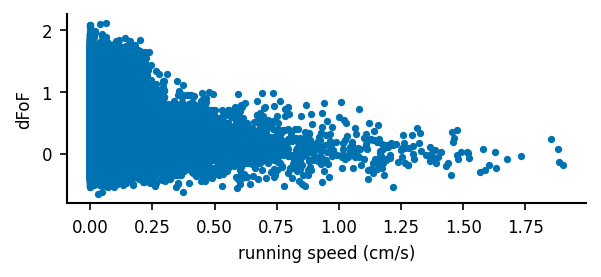

In [13]:
data.build_dFoF()
data.t_dFoF[-1]
data.build_pupil_diameter()

running_FaceCamera_sampled = data.build_running_speed(specific_time_sampling=data.t_rawFluo)
running_dFoF_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
pt.figure(figsize=(2,2))

plt.scatter(running_dFoF_sampled, data.dFoF[0,:])
plt.xlabel("running speed (cm/s)")
plt.ylabel("dFoF")


calculating dF/F with method "percentile" [...]

  ** all ROIs passed the positive F0 criterion ** 

-> dFoF calculus done !  (calculation took 0.0s)


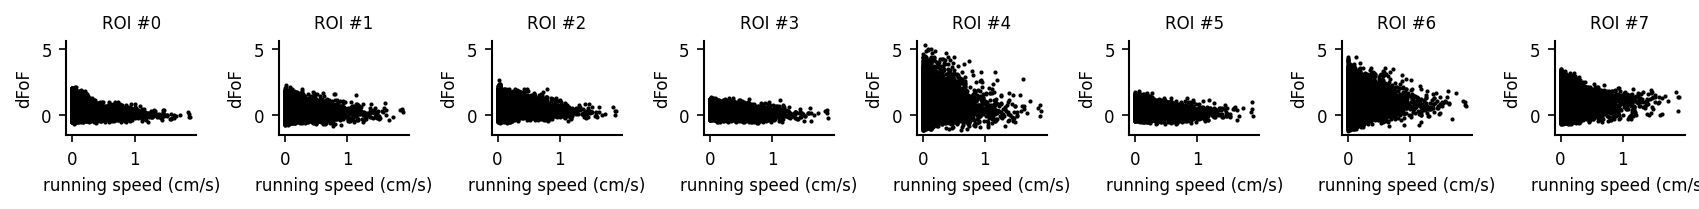

In [14]:


data.build_dFoF()
run_speed_sampled = data.build_running_speed(specific_time_sampling=data.t_dFoF)
n_ori = 8
ROIs = np.arange(0,8,1)
fig, AX = pt.figure(axes=(n_ori,1))
roi=15
for roi, ax in zip(ROIs, AX):
    pt.scatter(run_speed_sampled, 
            data.dFoF[roi,:],
            ax=ax)
    ax.set_xlabel("running speed (cm/s)")
    ax.set_ylabel("dFoF")
    ax.set_title(f'ROI #{roi}')
    
pt.set_common_ylims(AX)

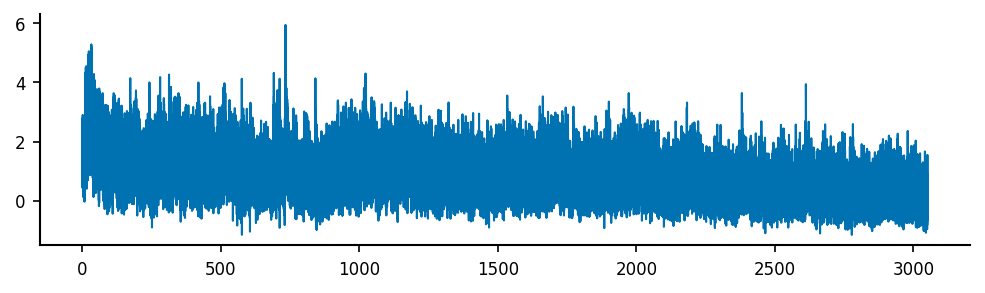

In [15]:
from matplotlib.pyplot import figure
fig = figure(figsize=(8, 2))
plt.plot(data.t_dFoF, data.dFoF[21])

In [16]:
import sklearn
from sklearn.linear_model import LinearRegression

In [23]:
x = np.array(run_speed_sampled).reshape((-1,1))
y = np.array(data.dFoF[3])
print(x)
print(y)

[[0.        ]
 [0.        ]
 [0.        ]
 ...
 [0.04497473]
 [0.04497473]
 [0.04497473]]
[ 0.9005201   0.62425333  0.52121055 ... -0.09575897 -0.07480323
  0.05063711]


In [18]:
model = LinearRegression()

In [24]:
model.fit(x,y)

LinearRegression()

In [31]:
r_sq = model.score(x,y)
print(f"coefficient of determination Rsquared: {r_sq}" )
print(f"intercept : {model.intercept_}")
print(f"slope : {model.coef_}")

coefficient of determination Rsquared: 0.005543938308486762
intercept : 0.3331694060940677
slope : [-0.20009423]
